# Tutorial: scCAMEL-SWAPLINE Mouse Dentate Gyrus to Human Glioblastoma

This tutorial demonstrates the SWAPLINE workflow with the published PyPI `scCAMEL` package. It trains a reference neural-network classifier on mouse dentate gyrus clusters, saves/reloads the model, and predicts human glioblastoma lineage-like cluster signals.


**Original Article:** [Neural network learning defines glioblastoma features to be of neural crest perivascular or radial glia lineages,"Sci. Adv.", 2022 ](https://pubmed.ncbi.nlm.nih.gov/35675414/)

**Package:** `scCAMEL` from PyPI, tested here with version `0.47b0`.

**Method:** [scCAMEL-SWAPLINE.v1](https://pubmed.ncbi.nlm.nih.gov/35675414/)


**Author:** [Yizhou Hu](https://staff.ki.se/people/yizhou-hu), **Research Group:** [Ernfors lab](https://ki.se/en/mbb/patrik-ernfors-group)

**Link of the datasets:** [Mouse Dentate Gyrus, Human glioblastoma](https://1drv.ms/f/s!AoNAwG-G6IN7mMI4FuP_jm_z7GQvwg?e=kCda72), **Dataset references:** [Hochgerner and Zeisel, et al.](https://pubmed.ncbi.nlm.nih.gov/29335606/), [Couturier, et al.](https://pubmed.ncbi.nlm.nih.gov/32641768/)

**Resource gene list**[cell cycle genes, Homologene-HumanMouse  ](https://1drv.ms/f/s!AoNAwG-G6IN7mMI6nPFlK9w--D9o4w?e=ajB7B2)

## Training

In [1]:
import datetime
today=f"{datetime.datetime.now():%Y-%m-%d}"
today

'2026-06-09'

In [2]:
import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.utils.data as Data
import torchvision
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch.utils.data as data_utils
from matplotlib import cm
import numpy as np
import pandas as pd
import pickle as pickle
from scipy.spatial.distance import cdist, pdist, squareform
import pandas as pd
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import StratifiedShuffleSplit
from collections import defaultdict
from sklearn import preprocessing
import matplotlib.patches as mpatches
import torch.nn.functional as F
import math
#import gpytorch

import urllib.request
import os.path
import os
import sys
import importlib.metadata as importlib_metadata
from pathlib import Path
from scipy.io import loadmat
from math import floor
import anndata

PROJECT_ROOT = Path("/mnt/e/YZstudio/OneDrive/Research/Dataset/Brain_Adult_mouse")
PUBLIC_DATASET = Path("/mnt/f/Dropbox/data/proj/PE_HYZ/PublicDataSet")
VERSION_ROOT = Path("/mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605")
OUTPUT_DIR = VERSION_ROOT / "outputs" / "swapline_pypi047b0_tutorial"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT_ROOT)

# Make plots inline
%pylab inline


%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/IPython/core/magics/pylab.py:162: UserWarning: pylab import has clobbered these variables: ['floor']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [3]:
torch.manual_seed(1)    # reproducible

In [4]:
import scCAMEL as scm
from scCAMEL import CamelPrefiltering
from scCAMEL import CamelSwapline
from scCAMEL import CamelEvo

SC_CAMEL_VERSION = importlib_metadata.version("scCAMEL")
print("Using installed scCAMEL:", SC_CAMEL_VERSION)
print("scCAMEL import path:", Path(scm.__file__).parent)
print("Tutorial outputs:", OUTPUT_DIR)


Using installed scCAMEL: 0.47b0
scCAMEL import path: /home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/scCAMEL
Tutorial outputs: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/swapline_pypi047b0_tutorial


In [5]:
os.chdir(PROJECT_ROOT)
Path.cwd()


PosixPath('/mnt/e/YZstudio/OneDrive/Research/Dataset/Brain_Adult_mouse')

In [6]:
scref=anndata.read(PROJECT_ROOT / "ZeiselDentateGyrus_Ref2023-05-27.h5ad")
scref


/home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/anndata/__init__.py:42: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


AnnData object with n_obs × n_vars = 5454 × 14545
    obs: 'Cluster', 'Color'

In [7]:
set(scref.obs["Cluster"])

{'Astrocytes',
 'Cajal-Retzius',
 'Cck-Tox',
 'Endo',
 'GABA',
 'Granule',
 'Microglia',
 'Mossy',
 'NFOL',
 'Neuroblast',
 'OLIG',
 'OPC',
 'PVM',
 'Peri/VLMC',
 'nIPC/Rgl'}

In [8]:
scref.obs.groupby(["Cluster"]).count()

/tmp/ipykernel_44346/1119954423.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scref.obs.groupby(["Cluster"]).count()


,Color
Cluster,
Astrocytes,335
Cajal-Retzius,93
Cck-Tox,27
Endo,165
GABA,99
Granule,3045
Microglia,169
Mossy,137
NFOL,35


In [9]:
#if the matrix is sparse matrix
#screfall.X=screfall.X.todense()

In [10]:

# Apply the function to balance clusters and label up-sampled items
scref= scm.CamelPrefiltering.balance_clusters_adata(scref, 'Cluster',5)
scref

/home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 13371 × 14545
    obs: 'Cluster', 'Color', 'upsampled'

In [11]:
scref.obs.groupby(["Cluster"]).count()

/tmp/ipykernel_44346/1119954423.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scref.obs.groupby(["Cluster"]).count()


,Color,upsampled
Cluster,,
Astrocytes,944,944
Cajal-Retzius,702,702
Cck-Tox,636,636
Endo,774,774
GABA,708,708
Granule,3045,3045
Microglia,778,778
Mossy,746,746
NFOL,644,644


## Prefiltering_and_SelectFeatures

In [12]:
# if needed scref.X=scref.X.todense()
scref.X=scref.X.todense()
scref=scm.CamelPrefiltering.DataScaling(scref)

/home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)


In [13]:
dfpdt=pd.DataFrame(scref.X.T,index=scref.var.index,columns=scref.obs.index)
dfpdt.shape

(14545, 13371)

In [14]:
path=str(PUBLIC_DATASET) + "/"
dictfilename1="Homologene_mouse2human_dict2.pickle"
dfpdt= scm.CamelPrefiltering.TransSpeciesGeneName(dfm=dfpdt, dictfilename=dictfilename1, path=path)
samegene=set(dfpdt.index)
len(samegene)


12516

In [15]:
dfpdt

,10X46_1_ACTCTATGGTACGT-1,10X43_1_AGGGACGATCTCCG-1,10X46_1_GACAACTGTTGACG-1,10X46_1_CTGTAACTGGTCTA-1,10X43_1_TGCAAGTGTCTCCG-1,10X43_1_GTAACGTGCCTAAG-1,10X43_1_ATCACGGAGGAGTG-1,10X43_1_AATTGTGAGTTGCA-1,10X43_1_TGGTCAGACTATTC-1,10X43_1_ACAGTCGAGGGACA-1,...,10X43_1_CTTTCAGAAACCAC-1,10X43_1_ATAACCCTCCTCAC-1,10X43_1_GCAGGCACACCCAA-1,10X43_1_CTTTCAGAAACCAC-1,10X43_1_CAACGAACCAGTCA-1,10X46_1_TGAACCGAATGCCA-1,10X43_1_GCAGGCACACCCAA-1,10X46_1_CTCGCATGTATCTC-1,10X43_1_GTATTCACCTAGTG-1,10X46_1_AAGACAGACAGTTG-1
A2M,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.000000,0.0
AAAS,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.000000,0.0
AACS,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.000000,0.0
AAED1,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.57404,0.000000,0.0,0.57404,0.000000,0.0,0.0,0.0,0.000000,0.0
AAGAB,0.0,0.000000,0.700669,0.826938,0.000000,1.424036,0.0,0.0,0.0,0.0,...,0.00000,1.042694,0.0,0.00000,0.000000,0.0,0.0,0.0,1.374609,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZXDC,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.000000,0.0
ZYG11B,0.0,0.000000,1.401339,0.826938,1.417607,0.000000,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.000000,0.0
ZYX,0.0,0.000000,0.000000,0.000000,0.708804,0.000000,0.0,0.0,0.0,0.0,...,0.00000,1.042694,0.0,0.00000,1.837025,0.0,0.0,0.0,0.000000,0.0
ZZEF1,0.0,0.696231,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.57404,0.000000,0.0,0.57404,0.000000,0.0,0.0,0.0,0.000000,0.0


In [16]:
scref2= anndata.AnnData(dfpdt.T.astype(float))
scref2

/home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 13371 × 12516

In [17]:
scref2.obs=scref.obs

In [18]:
scref=scref2.copy()

/home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [19]:
path=str(PUBLIC_DATASET) + '/'
filename='PANTHER_cell_cycle_genes.txt'
scref= scm.CamelPrefiltering.prefilter(datax=scref,filename=filename, path=path)


CamelRunning_Prefilter......
CamelRunning_Prefilter......Finished


In [20]:
scref=scm.CamelPrefiltering.DataScaling(scref)

In [21]:
scref.obs

,Cluster,Color,upsampled
10X46_1_ACTCTATGGTACGT-1,Granule,#b48c82,False
10X43_1_AGGGACGATCTCCG-1,Granule,#b48c82,False
10X46_1_GACAACTGTTGACG-1,Granule,#b48c82,False
10X46_1_CTGTAACTGGTCTA-1,Granule,#b48c82,False
10X43_1_TGCAAGTGTCTCCG-1,Granule,#b48c82,False
...,...,...,...
10X46_1_TGAACCGAATGCCA-1,PVM,#8b6564,True
10X43_1_GCAGGCACACCCAA-1,PVM,#8b6564,True
10X46_1_CTCGCATGTATCTC-1,PVM,#8b6564,True
10X43_1_GTATTCACCTAGTG-1,PVM,#8b6564,True


In [22]:
scref=scm.CamelPrefiltering.SelectFeatures(datax=scref, clustername='Cluster',methodname='Enrichment_shortcut', numbergenes=50, folderchange=1.5)

Camel...Running: clusteringValue1...
Camel...Running: clusteringValue2...
[Processing]-0%--6%--13%--20%--26%--33%--40%--46%--53%--60%--66%--73%--80%--86%--93%-Camel...Running: CrossChecking...
Camel...Running: output genelist...


In [23]:
len(scref.var.index[scref.var["MVgene"]])

2246

In [24]:
scref2=scref.copy()

/home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [25]:
########################################################
########################################################
#remeber to change the file path in tftable
########################################################
scref =scm.CamelPrefiltering.LabelGene_Scaling(datax=scref2,
                                                                TPTT=100000,     mprotogruop=scref2.obs["Cluster"].values, commongene=None,
                                                                                              sharedMVgenes=None, std_scaling=True,
    tftable=str(PUBLIC_DATASET / "FantomTF2CLUSTER_human_official.txt"), learninggroup="train")


CamelRunning---GenesScaling......
CamelRunning---TrainingGenesScaling......Finished


In [26]:
scref

AnnData object with n_obs × n_vars = 13371 × 12516
    obs: 'Cluster', 'Color', 'upsampled', 'mtrain_index'
    var: 'Filter1', 'MVgene', 'RefGeneList'
    uns: 'train_set_gene', 'mclasses_names'
    obsm: 'train_set_values'

## Neural-Network learning

In [27]:
net=scm.CamelPrefiltering.NNclassifer(
   datax=scref,
    epochNum=150,
    learningRate=0.005,
    verbose=0,
    optimizerMmentum=0.8,
    dropout=0.3,
    #imizer__nesterov=True,
    )

CamelRunning---NNclasffier_in_cpu.......
CamelRunning---NNclasffier_in_cpu.......Finished


## Accuracy plot, the overall clustering accuracy is ~95%

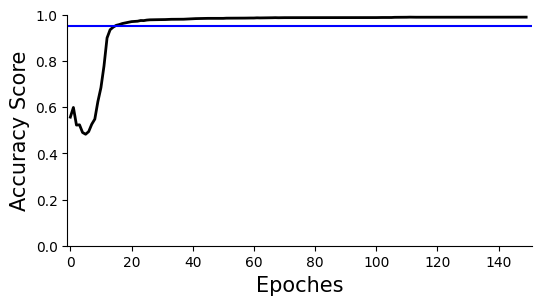

In [28]:
ax=scm.CamelPrefiltering.AccuracyPlot( nnModel=net, accCutoff=0.95,
                 Xlow=-1, Ylow=0.0, Yhigh=1,
               )

## Save and Reload the Trained Model

> **Note:** The published `scCAMEL 0.47b0` package includes `CamelSwapline.save_camel_model` and `CamelSwapline.load_camel_model`, so the tutorial uses those package helpers instead of redefining model serialization inside the notebook.


In [29]:
Path.cwd()


PosixPath('/mnt/e/YZstudio/OneDrive/Research/Dataset/Brain_Adult_mouse')

> **Tutorial note:** The checkpoint files are written to `OUTPUT_DIR / "camel_checkpoints2"` so they stay with the rest of the tutorial outputs.


In [30]:
Path.cwd()


PosixPath('/mnt/e/YZstudio/OneDrive/Research/Dataset/Brain_Adult_mouse')

In [31]:
# after net.fit(...)
paths = scm.CamelSwapline.save_camel_model(scref, net, out_dir=str(OUTPUT_DIR / "camel_checkpoints2"), prefix="camel_nn_mouseDG")
print("Saved files:", paths)


Saved files: {'meta': '/mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/swapline_pypi047b0_tutorial/camel_checkpoints2/camel_nn_mouseDG_meta.json', 'weights': '/mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/swapline_pypi047b0_tutorial/camel_checkpoints2/camel_nn_mouseDG_weights.pt', 'history': '/mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/swapline_pypi047b0_tutorial/camel_checkpoints2/camel_nn_mouseDG_history.json'}


In [32]:
net3= scm.CamelSwapline.load_camel_model(checkpoint_dir=str(OUTPUT_DIR / "camel_checkpoints2"), prefix="camel_nn_mouseDG",dropoutVal=0.3, device="cpu")

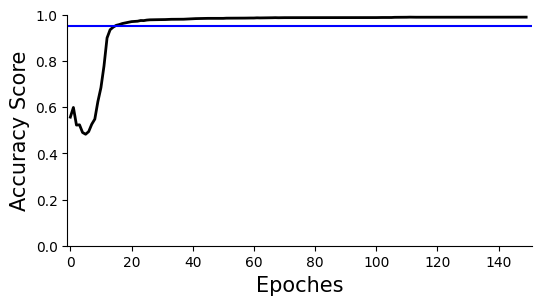

In [33]:
ax=scm.CamelPrefiltering.AccuracyPlot( nnModel=net3, accCutoff=0.95,
                 Xlow=-1, Ylow=0.0, Yhigh=1,
               )

## Make predition and visualization in Radar plot

In [34]:
net=scm.CamelPrefiltering.NNclassifer(
   datax=scref,
    epochNum=40,
    learningRate=0.005,
    verbose=0,
    optimizerMmentum=0.8,
    dropout=0.3,
    #imizer__nesterov=True,
    )

CamelRunning---NNclasffier_in_cpu.......
CamelRunning---NNclasffier_in_cpu.......Finished


In [35]:
scref

AnnData object with n_obs × n_vars = 13371 × 12516
    obs: 'Cluster', 'Color', 'upsampled', 'mtrain_index'
    var: 'Filter1', 'MVgene', 'RefGeneList'
    uns: 'train_set_gene', 'mclasses_names'
    obsm: 'train_set_values'

In [36]:
#if color is not defined: scref.obs[ 'color']
predefined_colors = pd.Series({
'Astrocytes':   [190,  10,  10],'Cajal-Retzius': [225, 160,  30],'Cck-Tox':    [217, 215,   7],
             'Endo':    [170, 180, 170], 'GABA':   [130, 140, 140],'Granule':    [180, 140, 130],
             'Microglia':  [100, 100, 240],'Mossy': [ 80, 235, 255],'NFOL':[190, 235, 255],
              'Neuroblast':[210, 255, 215],'OLIG':[230, 140, 120], 'OPC':  [255, 195,  28],
              'PVM':  [139, 101, 100],'Pericytes':  [252, 183,  26],'Radial Glia-like':   [214, 194,  39],
              'VLMC':  [255, 120, 155],'nIPC': [250, 145,  45],'hRgl2a':  [250, 125,  25],
              'hDA0':    [190, 200, 190],'hOPC':   [255,  35, 155],'hRN':     [199, 121,  41],
              'hNbGaba': [ 40,  55, 130],'hGaba':  [  7,  121, 61],'hOMTN':   [ 95, 186,  70],
              'hSert':   [ 50, 180, 180],'nIPC/Rgl':   [245, 205, 170], 'Peri/VLMC':   [185, 245, 30],
              'eSCc':[205,205,220]
})

In [37]:
#if color is not defined
#del scref.obs["color"]
#scref=scm.CamelSwapline.addcolor(datax=scref,clustername="Cluster", colorcode="color")
scref = scm.CamelSwapline.add_color2(scref, clustername="Cluster", colorcode="color",predef=predefined_colors)


In [38]:
#if want to define your own order
#scref.uns["mwanted_order"] =[ 'Mossy', 'Cajal-Retzius', 'Cck-Tox', 'GABA',  'Endo', 'Peri/VLMC', 'PVM', 'Microglia', 'Astrocytes', 'OLIG',
 #'NFOL', 'OPC', 'nIPC/Rgl','Neuroblast','Granule']

scref.uns["mwanted_order"] =list(sort(list(set(scref.obs["Cluster"]))))



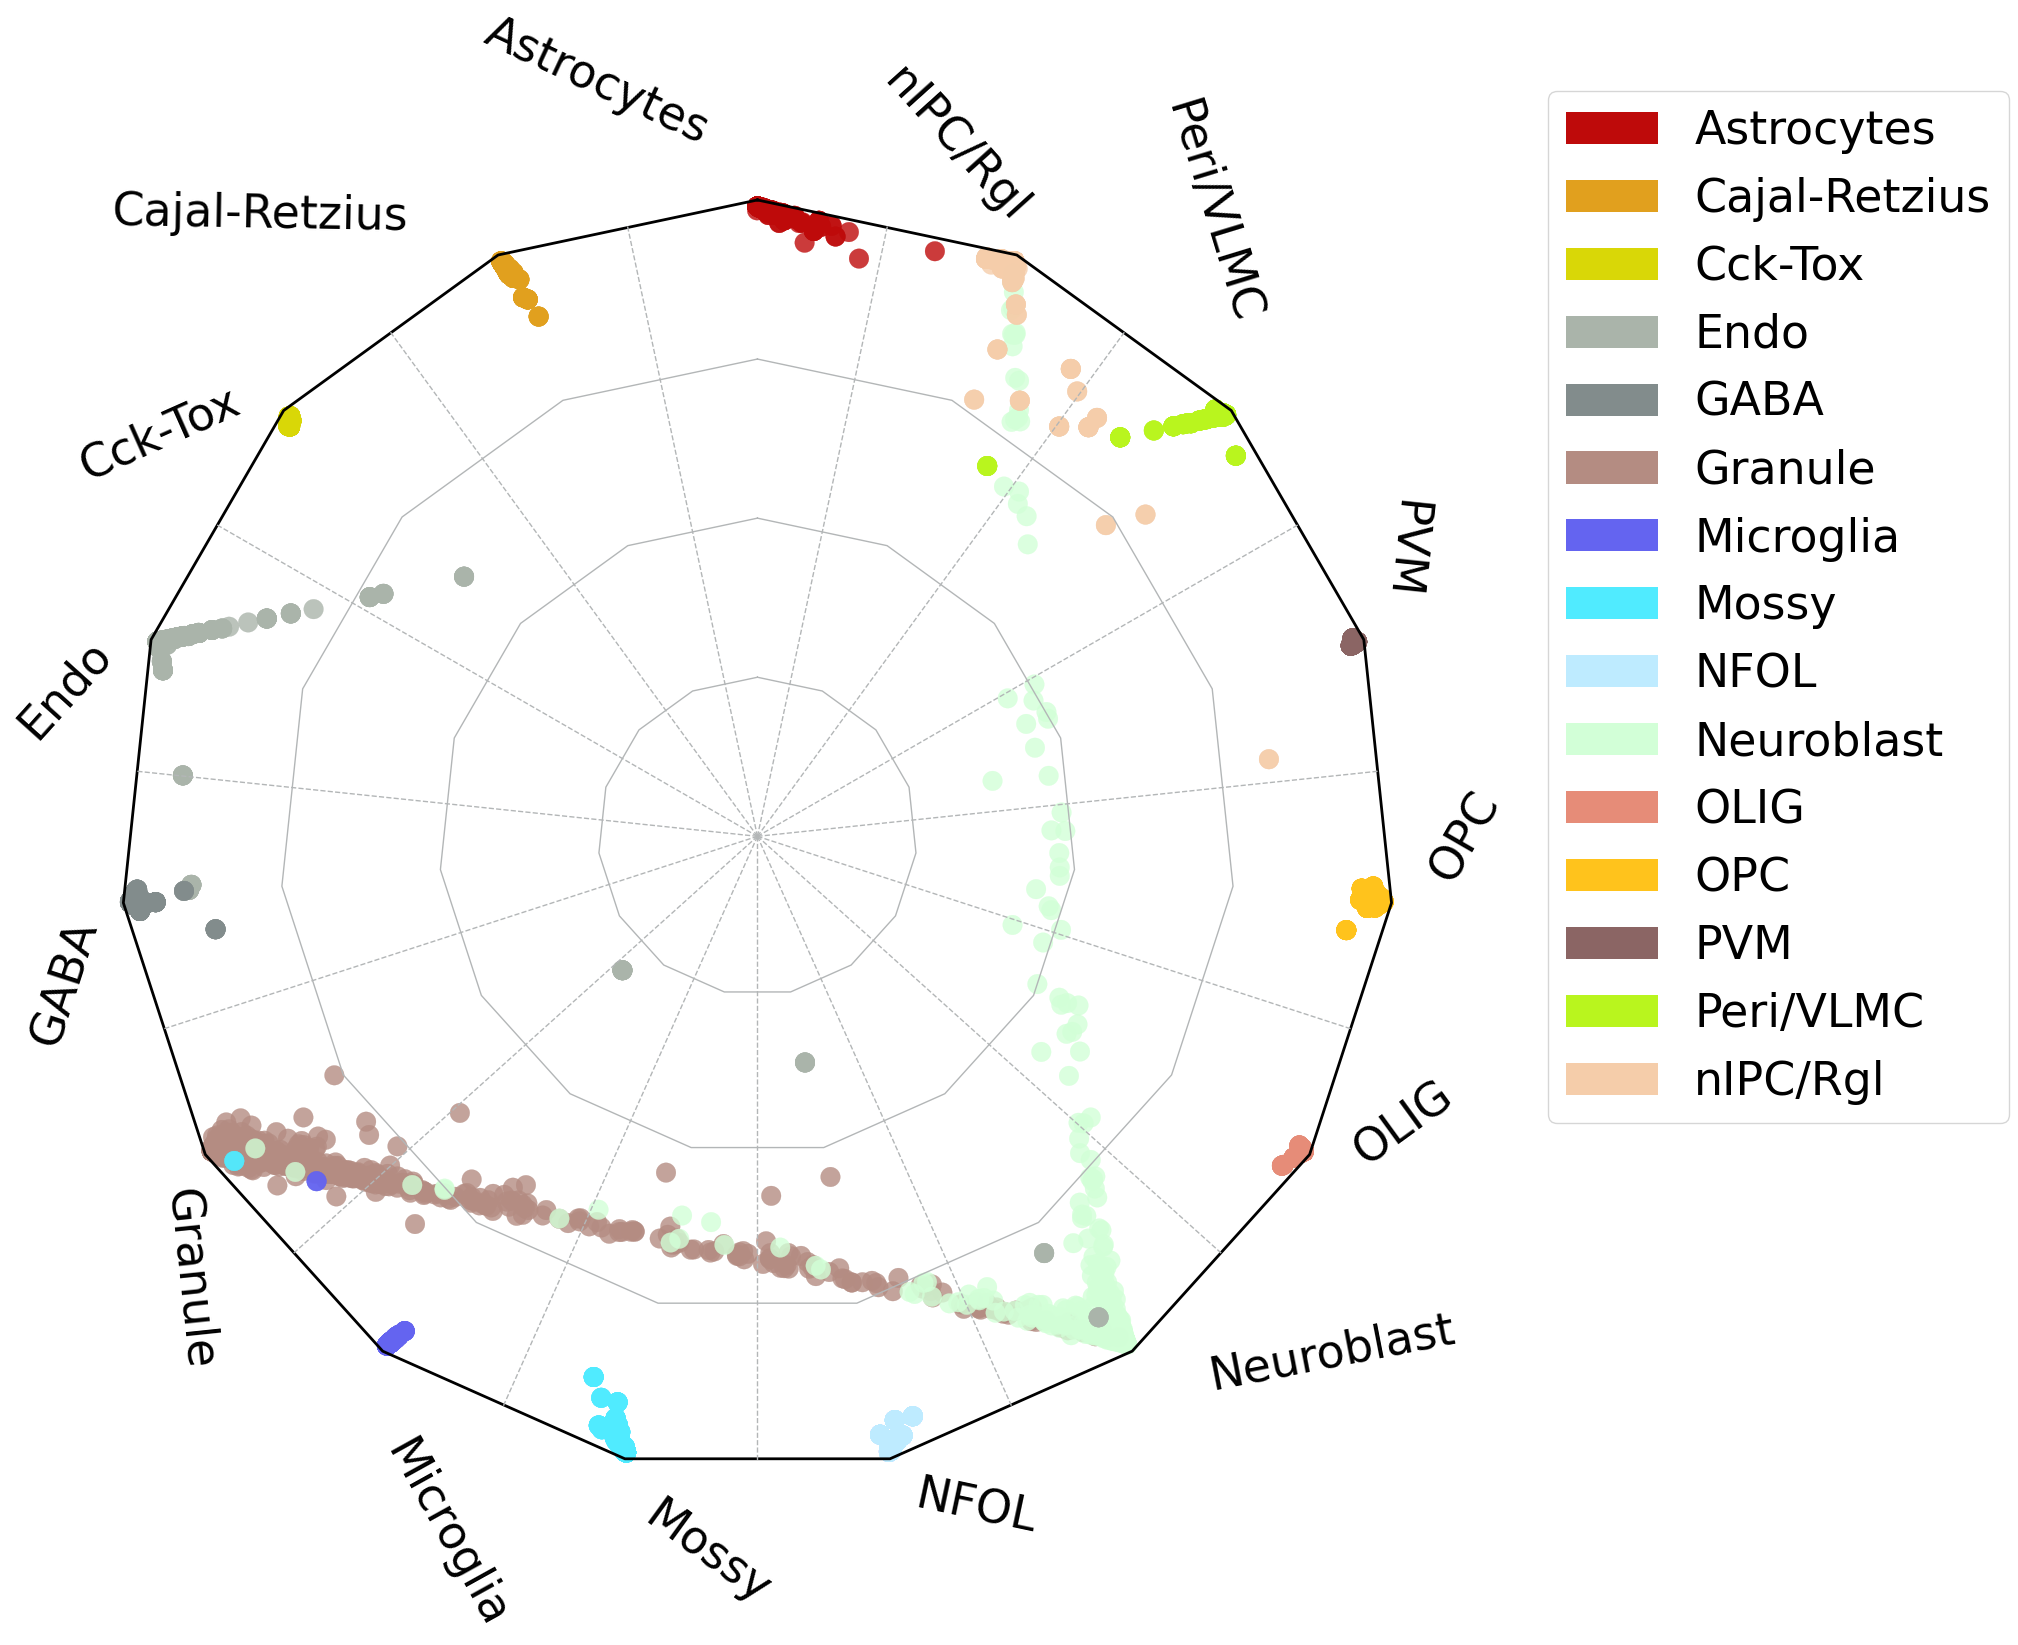

In [39]:
#radar  plot 
scref=scm.CamelSwapline.prediction(datax=scref, mcolor_dict=scref.uns["refcolor_dict"] ,net=net,learninggroup="train", radarplot=True,fontsizeValue=10,
                       ncolnm=3, bbValue=(1.5, 1.55)  )
#plt.savefig("upload_%s_RadarPlot_cluster.pdf"%today,bbox_inches='tight')

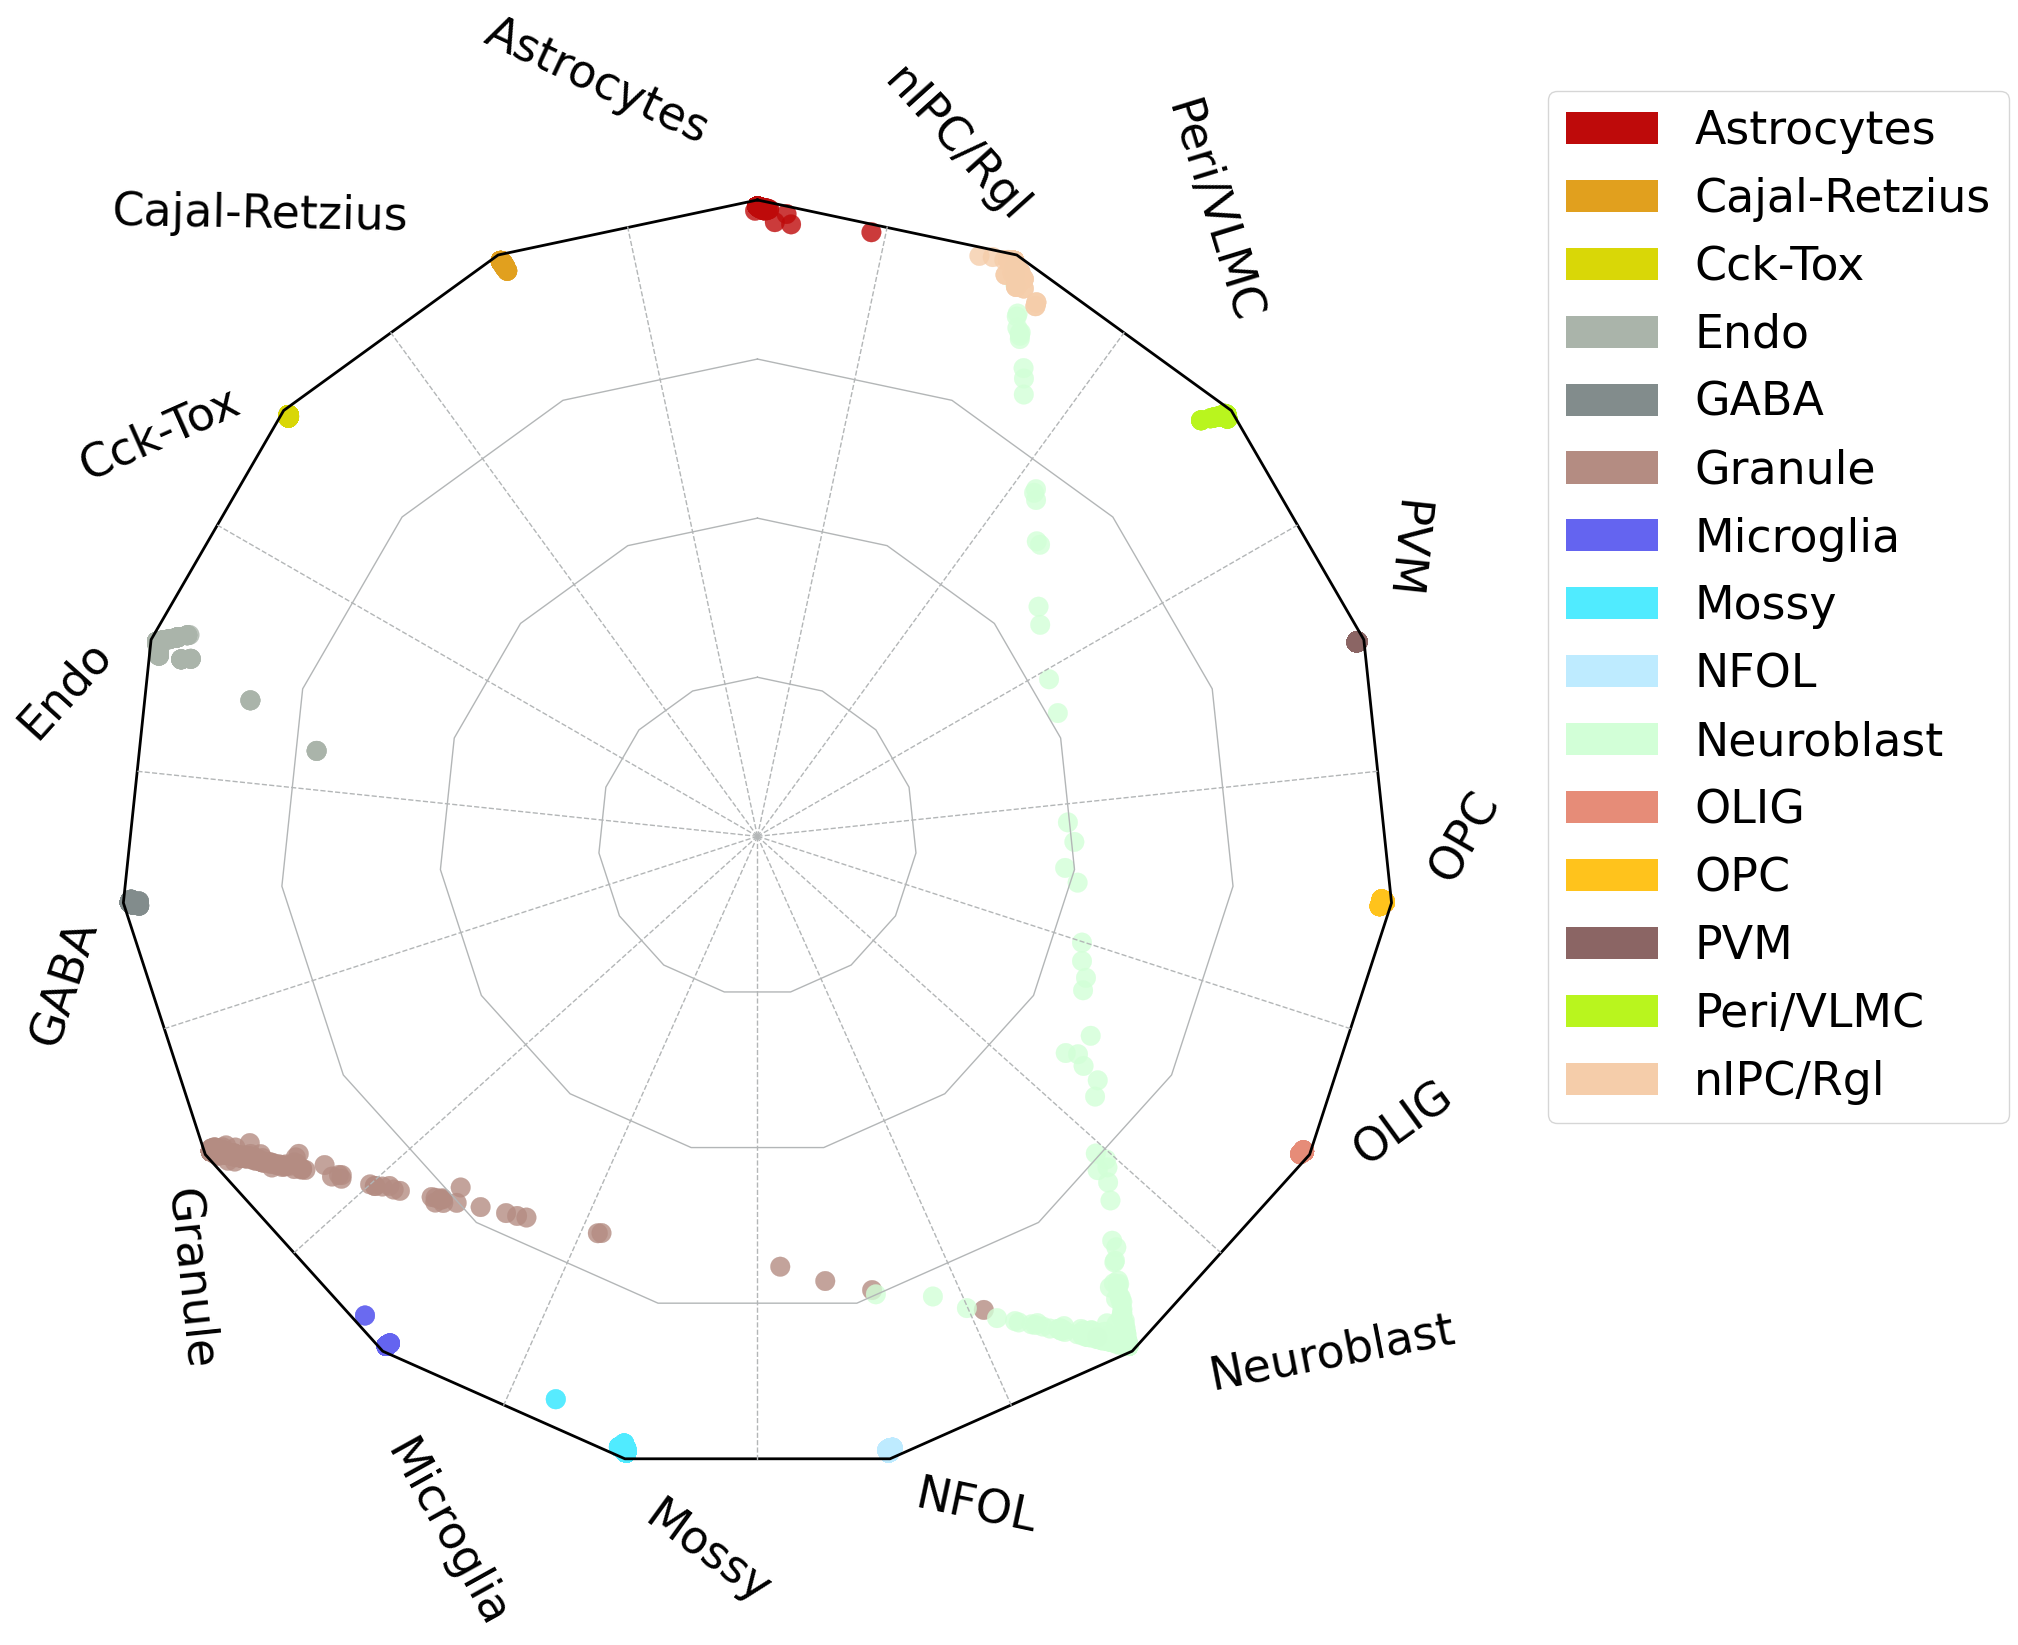

In [40]:
#radar  plot 
scref=scm.CamelSwapline.prediction(datax=scref, mcolor_dict=scref.uns["refcolor_dict"] ,net=net3,learninggroup="train", radarplot=True,fontsizeValue=10,
                       ncolnm=3, bbValue=(1.5, 1.55)  )
#plt.savefig("upload_%s_RadarPlot_cluster.pdf"%today,bbox_inches='tight')

## permutation control

In [41]:
## the whole data matrix is randomized, the red X represents 95% conficence of each cell-type

/home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/scCAMEL/CamelSwapline.py:1848: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.violinplot(scale="width", bw=0.4, cut=2, gridsize=100, saturation=0.9, scale_hue=False,
/home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/scCAMEL/CamelSwapline.py:1848: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(scale="width", bw=0.4, cut=2, gridsize=100, saturation=0.9, scale_hue=False,
/home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/scCAMEL/CamelSwapline.py:1848: FutureWarning: 

The `scale_hue` parameter has been replaced and will be removed in v0.15.0. Pass `common_norm=True` for the same effect.
  ax = sns.violinplot(scale="width", bw=0.4, cut=2, gridsize=100, saturation=0.9, scale_hue=False,
/home/huyiz/anaconda3

<Figure size 640x480 with 0 Axes>

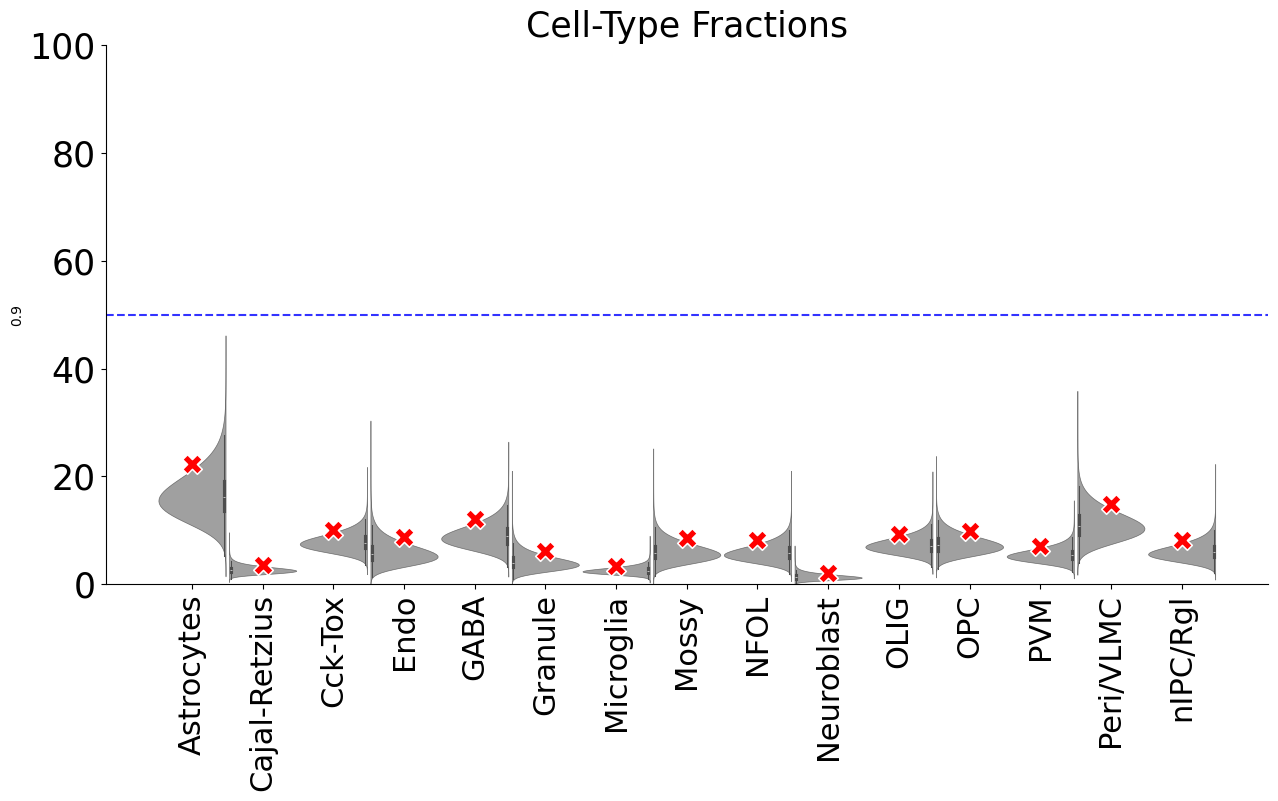

In [42]:
dftest0, ratiodf=scm.CamelSwapline.permutationTest(datax=scref,net=net,num=20, plotshow=True)

/home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/scCAMEL/CamelSwapline.py:1848: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.violinplot(scale="width", bw=0.4, cut=2, gridsize=100, saturation=0.9, scale_hue=False,
/home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/scCAMEL/CamelSwapline.py:1848: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(scale="width", bw=0.4, cut=2, gridsize=100, saturation=0.9, scale_hue=False,
/home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/scCAMEL/CamelSwapline.py:1848: FutureWarning: 

The `scale_hue` parameter has been replaced and will be removed in v0.15.0. Pass `common_norm=True` for the same effect.
  ax = sns.violinplot(scale="width", bw=0.4, cut=2, gridsize=100, saturation=0.9, scale_hue=False,
/home/huyiz/anaconda3

<Figure size 640x480 with 0 Axes>

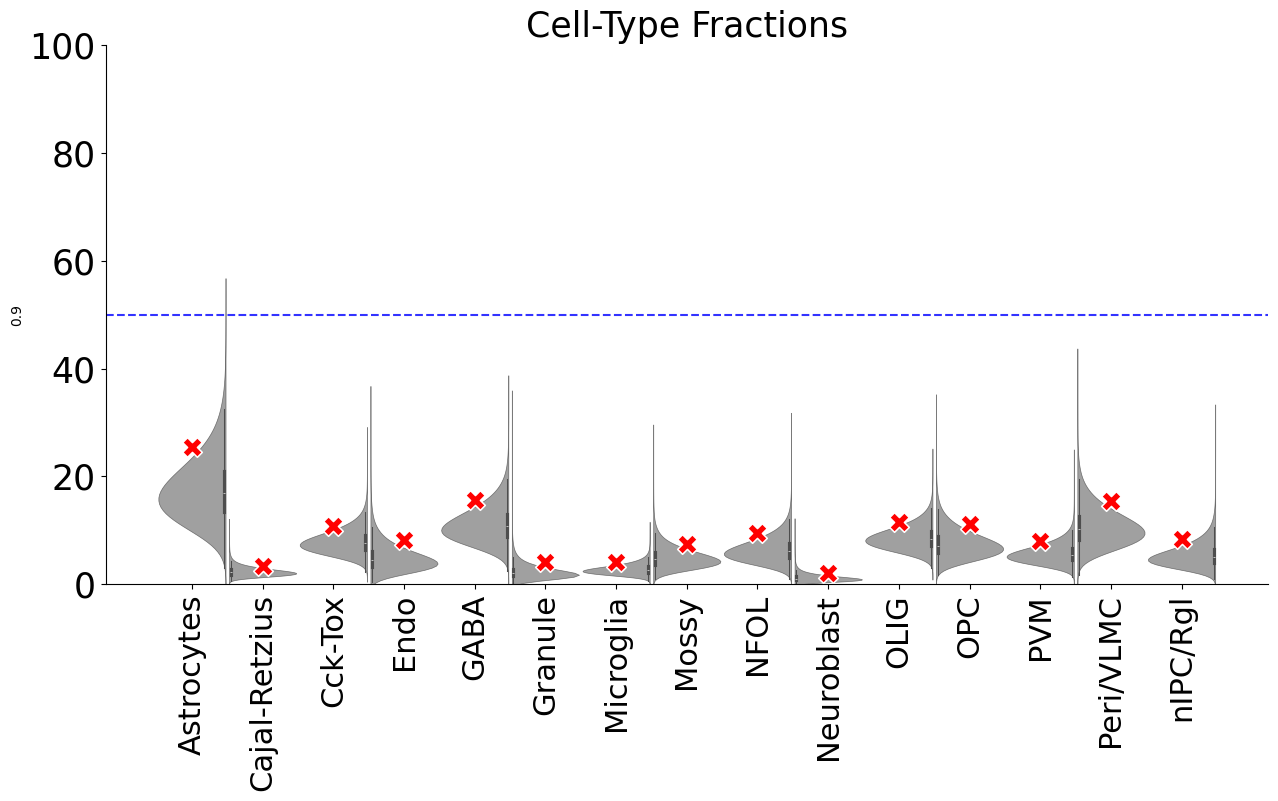

In [43]:
dftest0, ratiodf=scm.CamelSwapline.permutationTest(datax=scref,net=net3,num=20, plotshow=True)

## Cell_Type Purity

In [44]:
#The ratio of the purity entropy for each cluster based on their learning scores, is used as a measure of purity.
#The function returns a pandas dataframe sorted by the purity score

<Figure size 640x480 with 0 Axes>

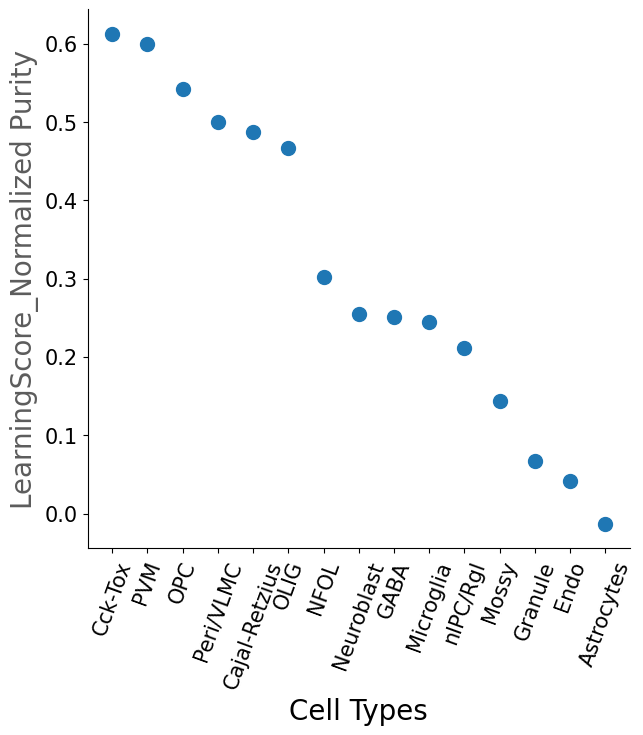

In [45]:
dfpurity1=scm.CamelSwapline.PurityEstimationLearningScore(datax=scref, clusterlist="Cluster", elbow=False, figureplot=True)

## association between cell-types

In [46]:
scref

AnnData object with n_obs × n_vars = 13371 × 12516
    obs: 'Cluster', 'Color', 'upsampled', 'mtrain_index', 'color'
    var: 'Filter1', 'MVgene', 'RefGeneList'
    uns: 'train_set_gene', 'mclasses_names', 'refcolor_dict', 'mwanted_order', 'Celltype_Score_RefCellType', 'Celltype_OrderNumber'
    obsm: 'train_set_values', 'Celltype_Score', 'CelltypeScoreCoordinates'

In [47]:
# the heatmap of hierarchical clustering represents the cell-type similarity or association
#color from dark purple to light yellow represents the association from low to high
#number inside of eahc square indicating the association value.

/home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/scCAMEL/CamelSwapline.py:2472: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfpb2 = dfprob.groupby(["Cluster"]).mean()


<Figure size 1500x1500 with 0 Axes>

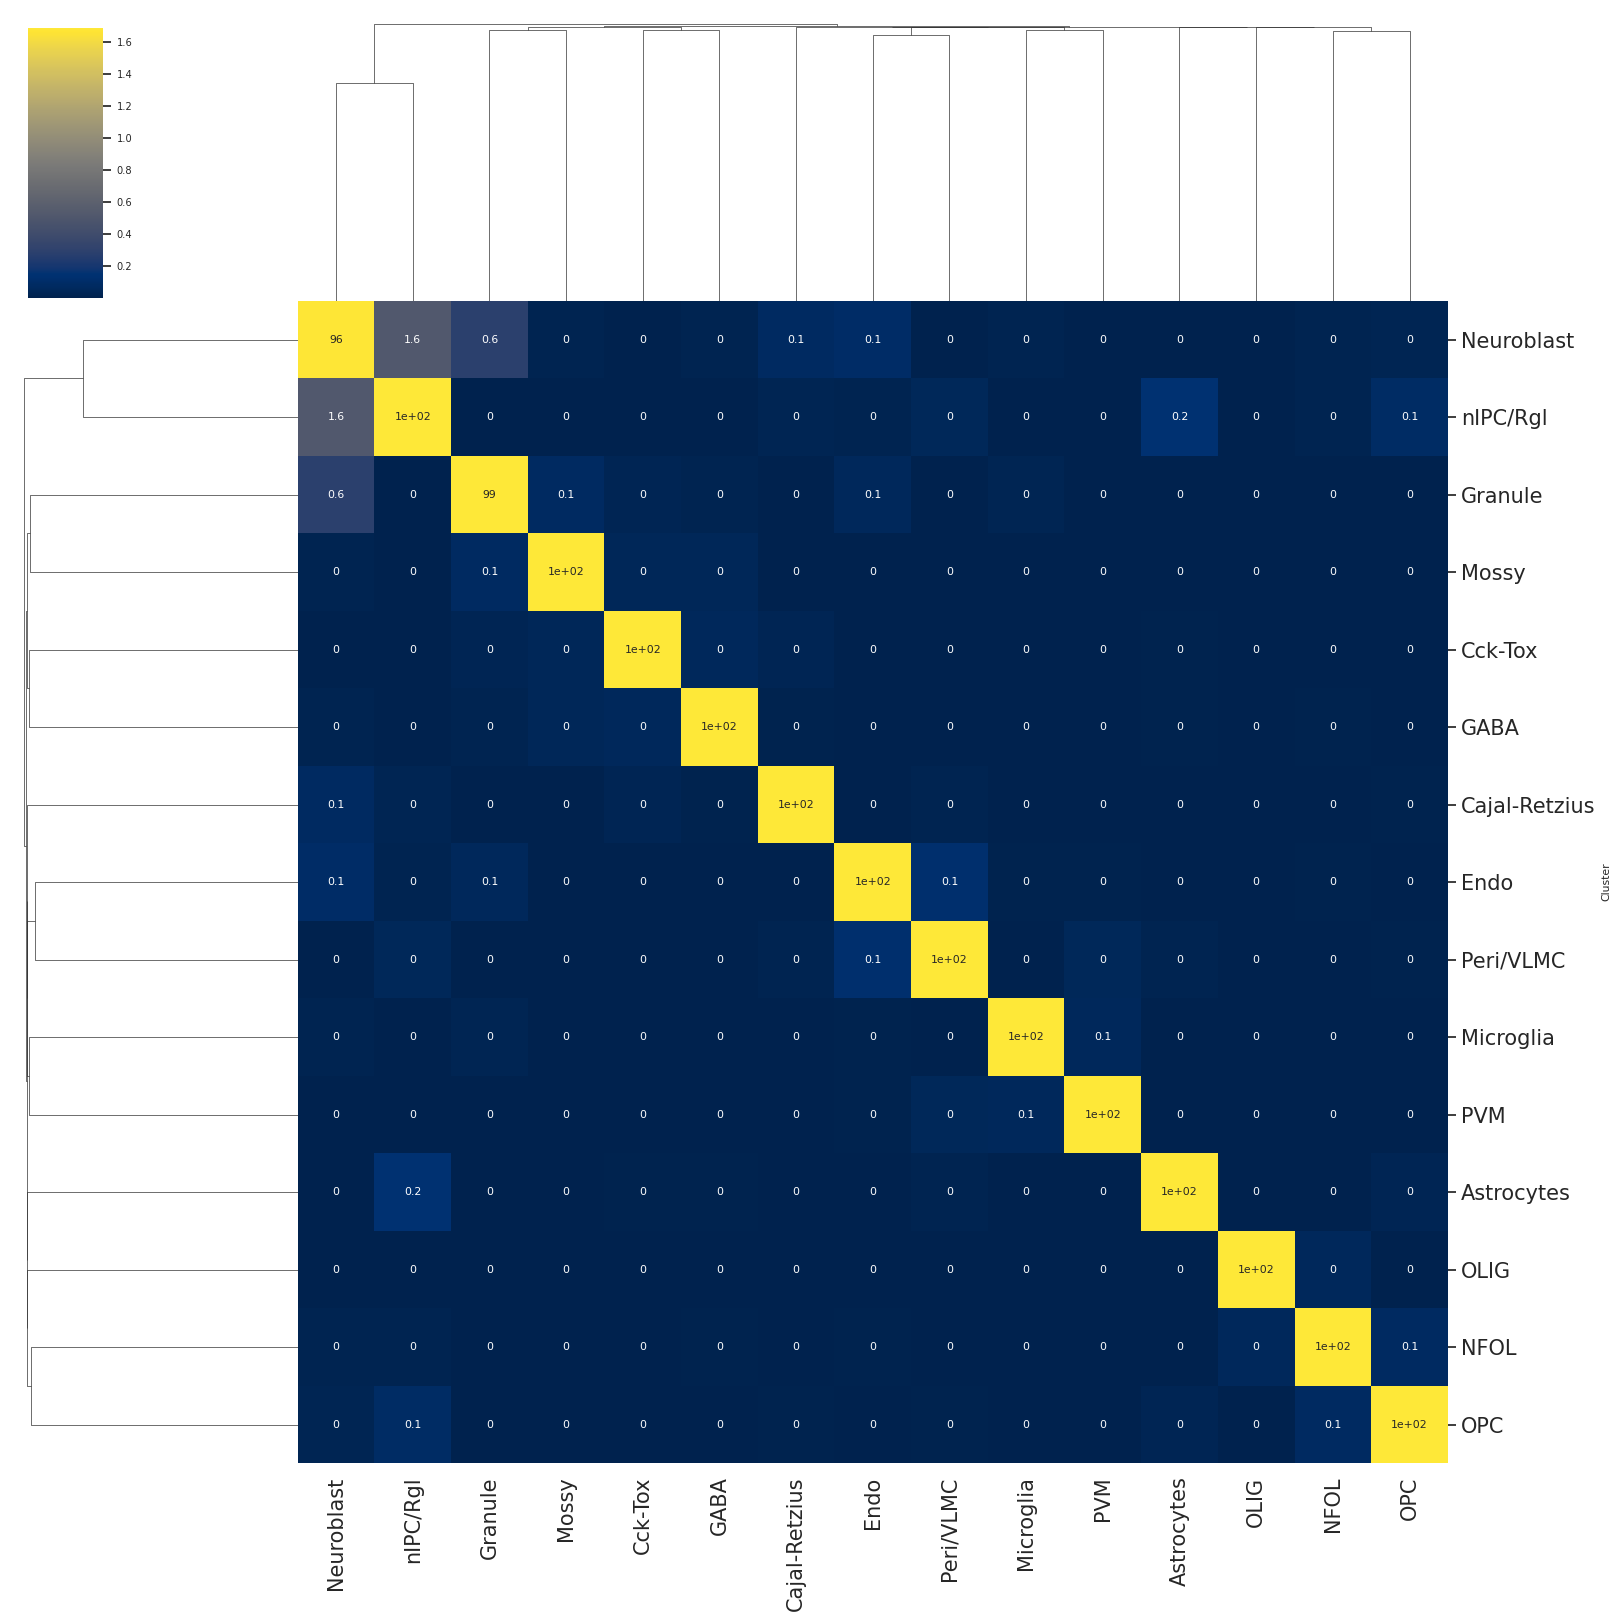

In [48]:
scm.CamelSwapline.CellTypeSimilarity(datax=scref, labelnum=True,  metricvalue='correlation',methodvalue="complete")

/home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/scCAMEL/CamelSwapline.py:2472: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfpb2 = dfprob.groupby(["Cluster"]).mean()


<Figure size 1500x1500 with 0 Axes>

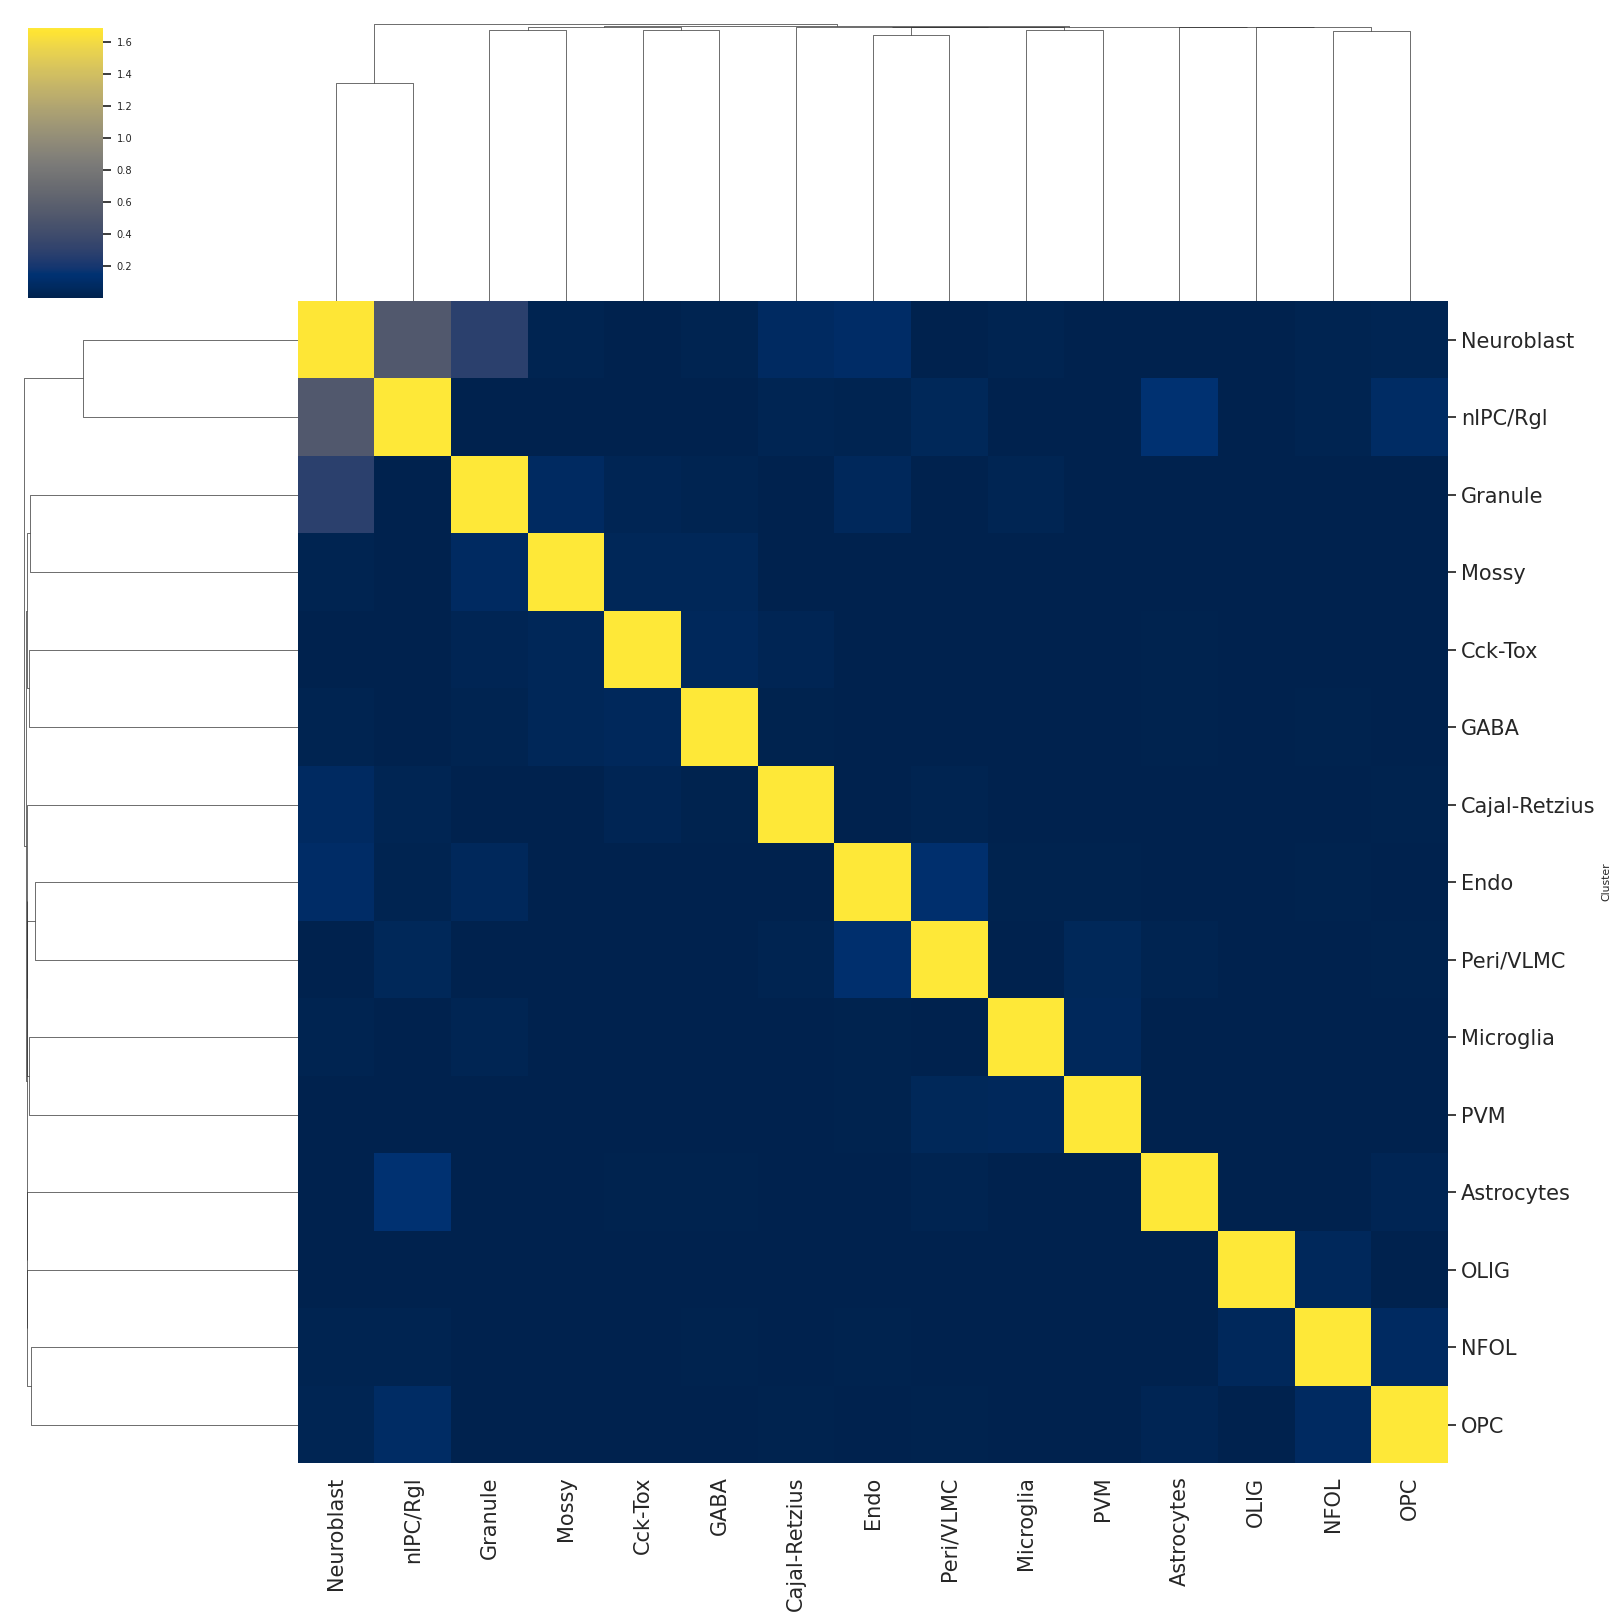

In [49]:
scm.CamelSwapline.CellTypeSimilarity(datax=scref, labelnum=False,  metricvalue='correlation',methodvalue="complete")

## Save data

In [50]:
scref

AnnData object with n_obs × n_vars = 13371 × 12516
    obs: 'Cluster', 'Color', 'upsampled', 'mtrain_index', 'color'
    var: 'Filter1', 'MVgene', 'RefGeneList'
    uns: 'train_set_gene', 'mclasses_names', 'refcolor_dict', 'mwanted_order', 'Celltype_Score_RefCellType', 'Celltype_OrderNumber'
    obsm: 'train_set_values', 'Celltype_Score', 'CelltypeScoreCoordinates'

In [51]:
Path.cwd()


PosixPath('/mnt/e/YZstudio/OneDrive/Research/Dataset/Brain_Adult_mouse')

In [52]:
scref.uns["refcolor_dict"]= predefined_colors

In [53]:
work_dir=str(OUTPUT_DIR)
QueryName="ZeiselMouseDG"
TrainingName="ZeiselMouseDG"
filename="%s_%s_Ref%s_MergeCluster.h5ad"%(QueryName,TrainingName,today)


In [54]:
os.path.join(work_dir,filename)

'/mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/swapline_pypi047b0_tutorial/ZeiselMouseDG_ZeiselMouseDG_Ref2026-06-09_MergeCluster.h5ad'

In [55]:
del scref.uns['refcolor_dict']

In [56]:
CamelSwapline.write_data(adatax=scref,filename=filename,filepath=work_dir)

In [57]:
#if color is not defined: scref.obs[ 'color']
scref.uns['refcolor_dict'] = pd.Series({
'Astrocytes':   [190,  10,  10],'Cajal-Retzius': [225, 160,  30],'Cck-Tox':    [217, 215,   7],
             'Endo':    [170, 180, 170], 'GABA':   [130, 140, 140],'Granule':    [180, 140, 130],
             'Microglia':  [100, 100, 240],'Mossy': [ 80, 235, 255],'NFOL':[190, 235, 255],
              'Neuroblast':[210, 255, 215],'OLIG':[230, 140, 120], 'OPC':  [255, 195,  28],
              'PVM':  [139, 101, 100],'Pericytes':  [252, 183,  26],'Radial Glia-like':   [214, 194,  39],
              'VLMC':  [255, 120, 155],'nIPC': [250, 145,  45],'hRgl2a':  [250, 125,  25],
              'hDA0':    [190, 200, 190],'hOPC':   [255,  35, 155],'hRN':     [199, 121,  41],
              'hNbGaba': [ 40,  55, 130],'hGaba':  [  7,  121, 61],'hOMTN':   [ 95, 186,  70],
              'hSert':   [ 50, 180, 180],'nIPC/Rgl':   [245, 205, 170], 'Peri/VLMC':   [185, 245, 30],
              'eSCc':[205,205,220]
})

In [58]:
os.chdir(PROJECT_ROOT)
Path.cwd()


PosixPath('/mnt/e/YZstudio/OneDrive/Research/Dataset/Brain_Adult_mouse')

In [59]:
import scanpy as sc

In [60]:
scref=sc.read(OUTPUT_DIR / filename)
scref


/home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 13371 × 12516
    obs: 'Cluster', 'Color', 'upsampled', 'mtrain_index', 'color'
    var: 'Filter1', 'MVgene', 'RefGeneList'
    uns: 'Celltype_OrderNumber', 'Celltype_Score_RefCellType', 'mclasses_names', 'mwanted_order', 'train_set_gene'
    obsm: 'CelltypeScoreCoordinates', 'Celltype_Score', 'train_set_values'

In [61]:
net3= scm.CamelSwapline.load_camel_model(checkpoint_dir=str(OUTPUT_DIR / "camel_checkpoints2"), prefix="camel_nn_mouseDG",dropoutVal=0.3, device="cpu")

## Prediction

## Couturier2020_humanGlioblastoma

In [62]:
os.chdir(PROJECT_ROOT)
Path.cwd()


PosixPath('/mnt/e/YZstudio/OneDrive/Research/Dataset/Brain_Adult_mouse')

In [63]:
scpdt=anndata.read(PROJECT_ROOT / "Couturier2020_DevGBM_Ref2023-05-27.h5ad")


/home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/anndata/__init__.py:42: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [64]:
set(scpdt.obs["Cluster"])

{'Astro', 'Mesenchymal', 'Neuronal', 'Oligo', 'Progenitor', 'Unassigned'}

In [65]:
scpdt

AnnData object with n_obs × n_vars = 18475 × 33660
    obs: 'Patient', 'Cluster', 'Color'

In [66]:
scpdt.var.index

Index(['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1', 'A2ML1', 'A2ML1-AS1',
       'A2ML1-AS2', 'A3GALT2', 'A4GALT',
       ...
       'ZXDC', 'ZYG11A', 'ZYG11B', 'ZYX', 'ZZEF1', 'ZZZ3', 'bP-21264C1.2',
       'bP-2171C21.3', 'bP-2189O9.3', 'hsa-mir-1253'],
      dtype='object', length=33660)

In [67]:
scpdt.X=scpdt.X.todense()

/home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)


In [68]:
scpdt2=scpdt.copy()
scpdt2=scm.CamelPrefiltering.DataScaling(scpdt2)

In [69]:
########################################################
########################################################
#remeber to change the file path in tftable
########################################################
########################################################
scpdt =scm.CamelPrefiltering.MVgene_Scaling(datax=scpdt2,TPTT=0,   commongene=scref.var.index.tolist(),  
                                        sharedMVgenes=scref.uns[ 'train_set_gene'].tolist(),
                                                                                            std_scaling=True,score=None, thrs=None,  mprotogruop=None,
    tftable=str(PUBLIC_DATASET / "FantomTF2CLUSTER_human_official.txt"), learninggroup="test")
scpdt.uns["mwanted_order"] =list(sort(list(set(scpdt.obs["Cluster"]))))


CamelRunning---GenesScaling......
CamelRunning---TestGenesScaling......Finished


In [70]:
scpdt

AnnData object with n_obs × n_vars = 18475 × 33660
    obs: 'Patient', 'Cluster', 'Color', 'mtrain_index'
    var: 'RefGeneList'
    uns: 'train_set_gene', 'mclasses_names', 'mwanted_order'
    obsm: 'test_set_values'

In [71]:
#del scpdt.obs["color"]

In [72]:
# if color is not definedi
#scpdt=scm.CamelSwapline.addcolor(datax=scpdt,clustername="Cluster", colorcode="color")

In [73]:
scpdt.uns["refcolor_dict"] = pd.Series({'Astro': [100, 100, 240], 'Neuronal':   [ 0, 86,  255],
              'Mesenchymal':  [55, 120, 55], 'Oligo': [ 255,185, 5], 'Unassigned':  [192,192,192],
             'Progenitor':    [190, 0, 0]})

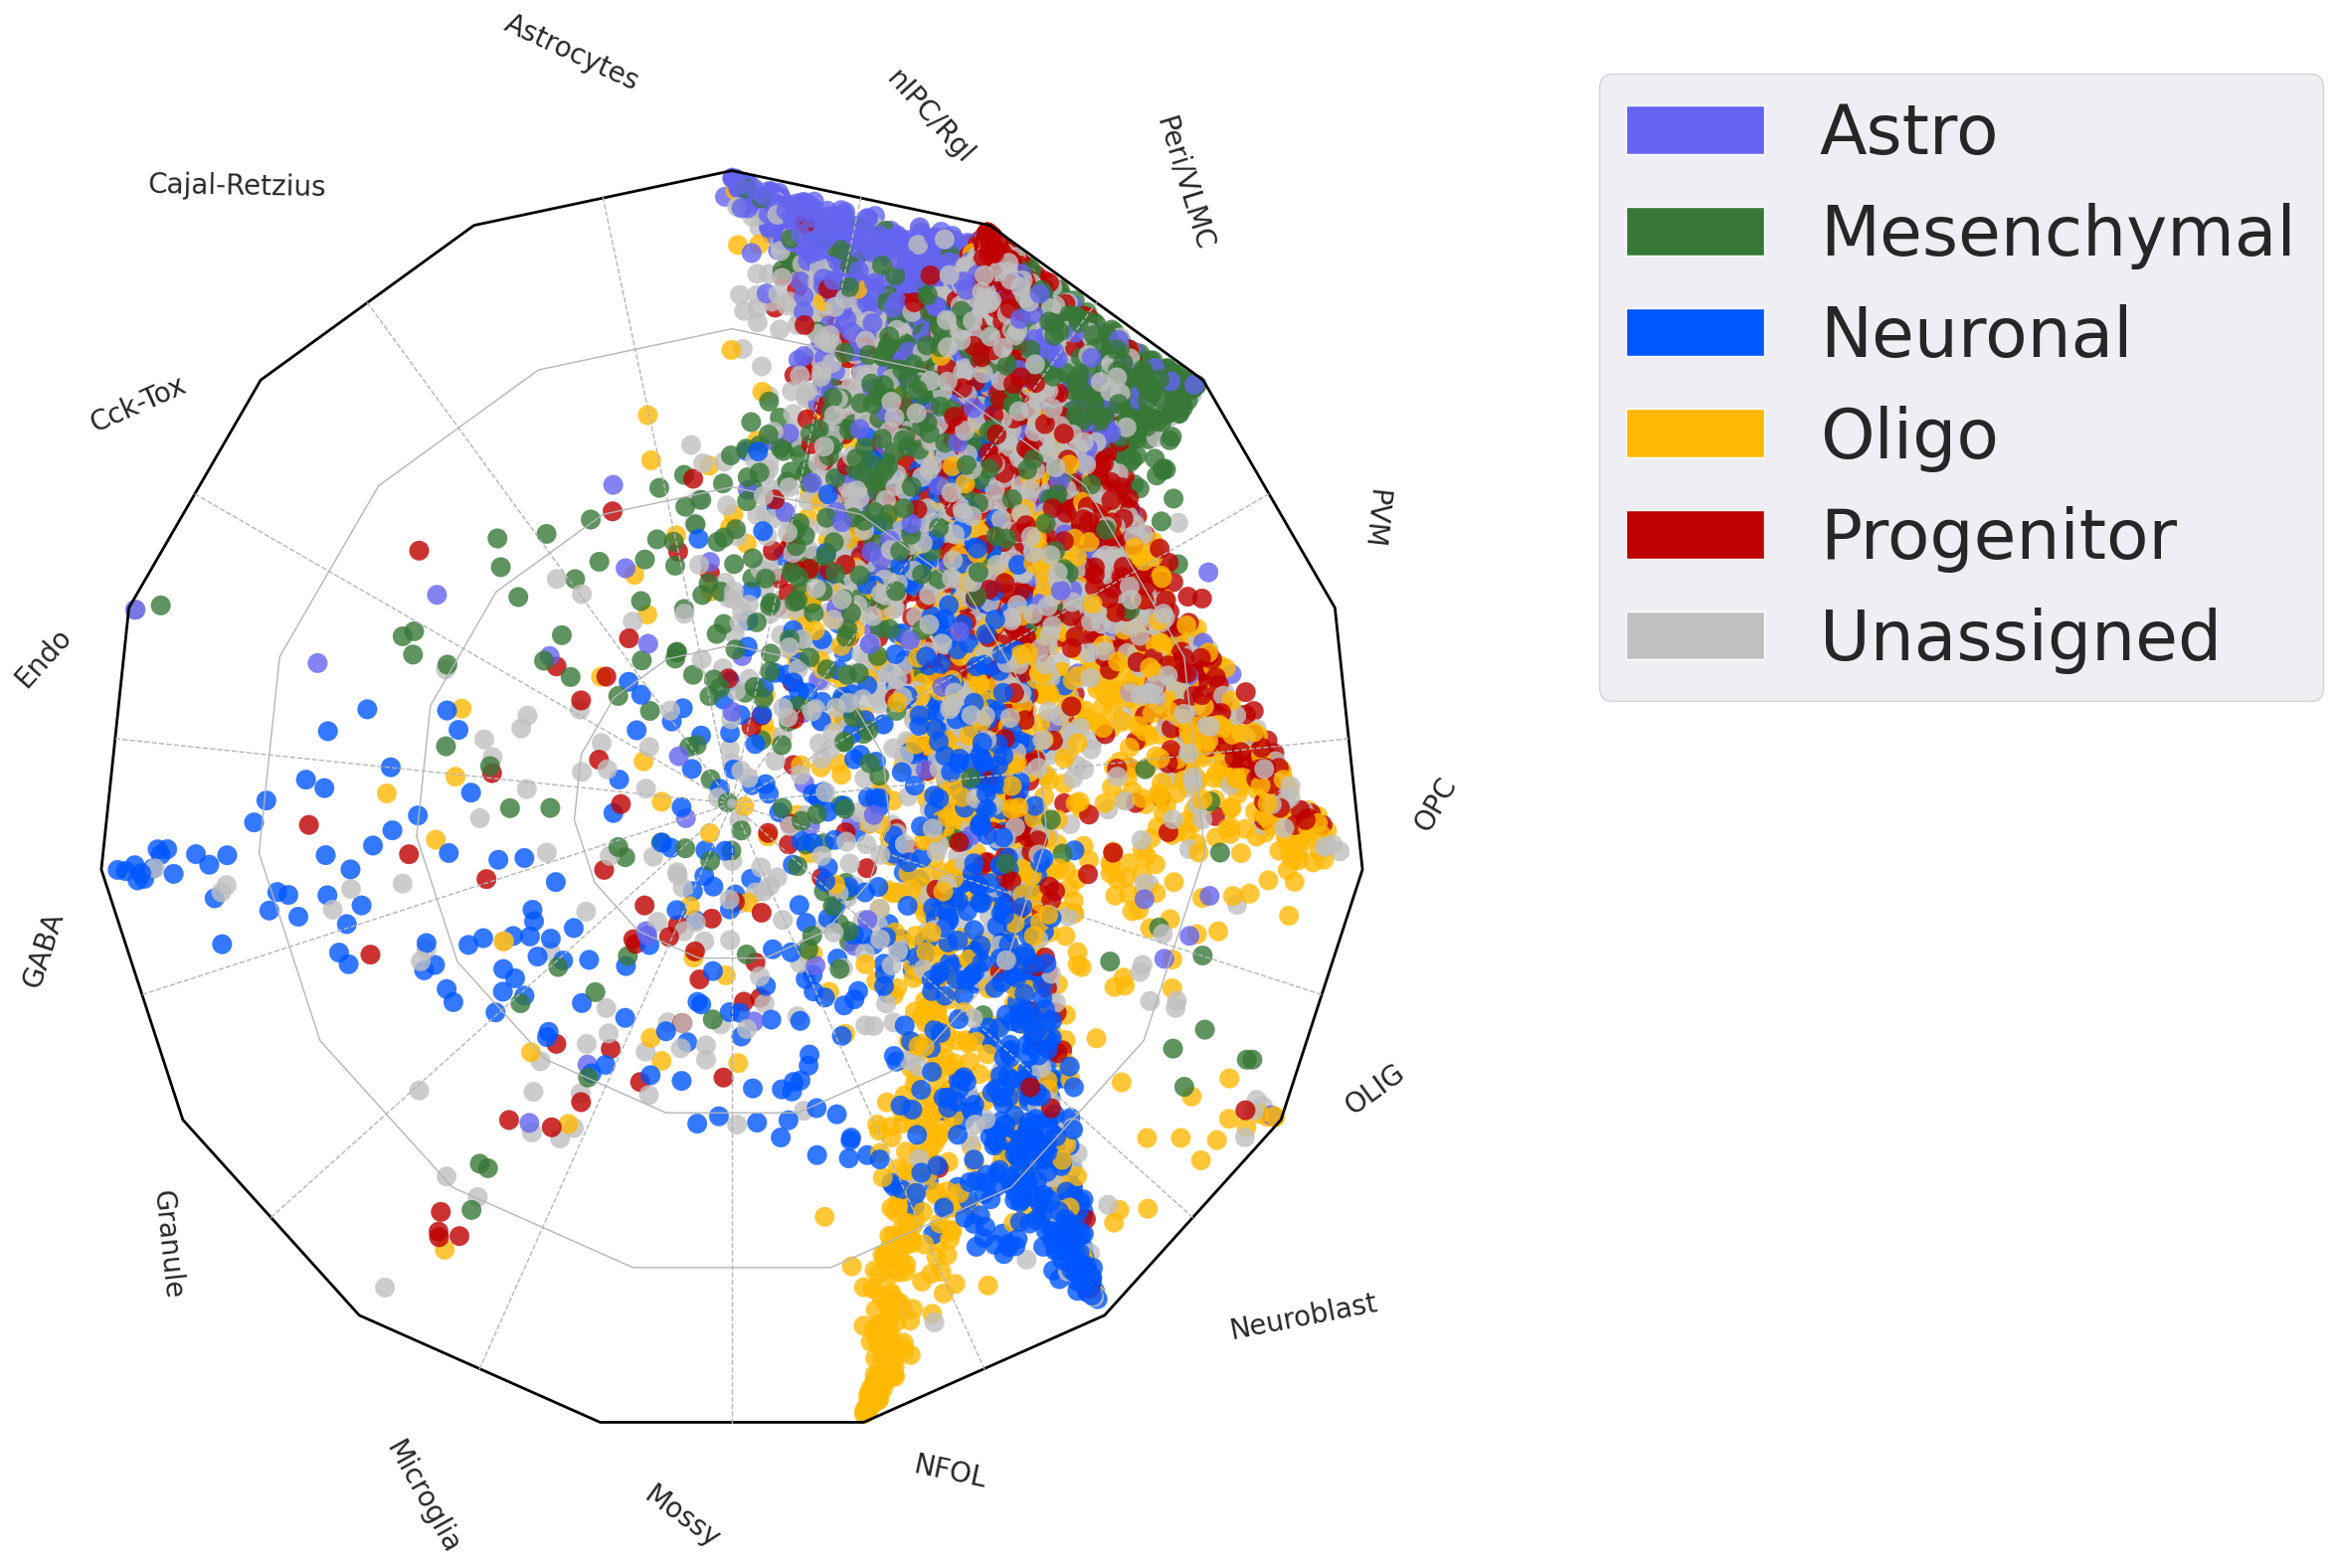

In [74]:
test=scm.CamelSwapline.prediction(datax=scpdt, mcolor_dict=pd.Series(scpdt.uns["refcolor_dict"]),net=net3,
                                  learninggroup="test", radarplot=True, fontsizeValue=35,
                  datarefplot=scref,ncolnm=1, bbValue=(1.1, 1.05))

In [75]:
scpdt

AnnData object with n_obs × n_vars = 18475 × 33660
    obs: 'Patient', 'Cluster', 'Color', 'mtrain_index'
    var: 'RefGeneList'
    uns: 'train_set_gene', 'mclasses_names', 'mwanted_order', 'refcolor_dict', 'Celltype_Score_RefCellType', 'Celltype_OrderNumber'
    obsm: 'test_set_values', 'Celltype_Score', 'CelltypeScoreCoordinates'

In [76]:
genename=sort(list(set(scpdt.obs["Cluster"])))
name=sort(list(set(scref.obs["Cluster"])))

/home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/scCAMEL/CamelSwapline.py:883: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


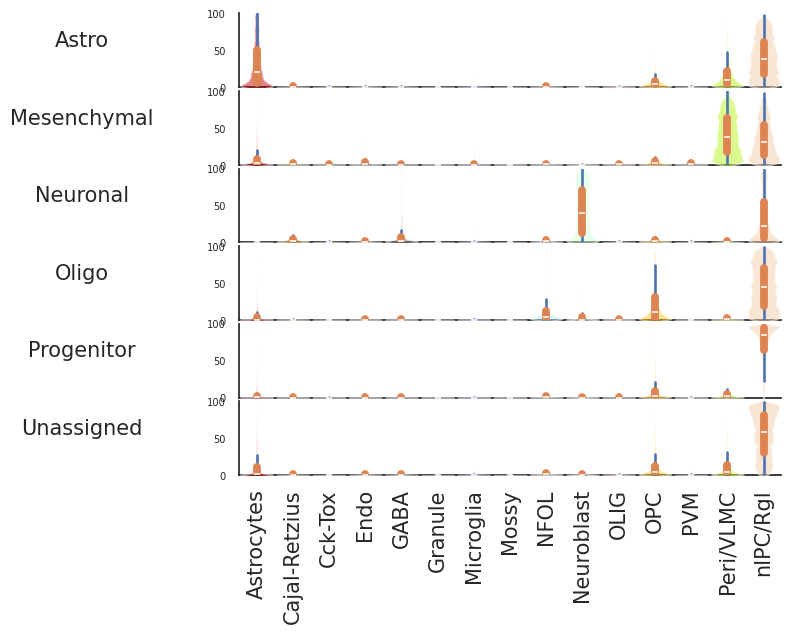

In [77]:
dfprob=pd.DataFrame(scpdt.obsm['Celltype_Score'])
dfprob.columns=scpdt.uns['Celltype_Score_RefCellType']
dfprob.index=scpdt.obs.index
dfmk=dfprob.astype(float).join(scpdt.obs["Cluster"],how="inner").T
dfprob=CamelSwapline.CellTypeSimilarityViolinPlot(datax=scpdt, dataref=scref)

##  Save data

In [78]:
Path.cwd()


PosixPath('/mnt/e/YZstudio/OneDrive/Research/Dataset/Brain_Adult_mouse')

In [79]:
scpdt

AnnData object with n_obs × n_vars = 18475 × 33660
    obs: 'Patient', 'Cluster', 'Color', 'mtrain_index'
    var: 'RefGeneList'
    uns: 'train_set_gene', 'mclasses_names', 'mwanted_order', 'refcolor_dict', 'Celltype_Score_RefCellType', 'Celltype_OrderNumber'
    obsm: 'test_set_values', 'Celltype_Score', 'CelltypeScoreCoordinates'

In [80]:
work_dir=str(OUTPUT_DIR)
QueryName="Couturier2020"
TrainingName="ZeiselMouseDG"
filename="%s_%s_Ref%s_MergeCluster.h5ad"%(QueryName,TrainingName,today)


In [81]:
os.path.join(work_dir,filename)

'/mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260605/outputs/swapline_pypi047b0_tutorial/Couturier2020_ZeiselMouseDG_Ref2026-06-09_MergeCluster.h5ad'

In [82]:
del scpdt.uns["refcolor_dict"]

In [83]:
CamelSwapline.write_data(adatax=scpdt,filename=filename,filepath=work_dir)